In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")

file_path = '/content/drive/MyDrive/visualizacion_de_datos/StreamView_Analytics_Dataset.xlsx'

df_users = pd.read_excel(file_path, sheet_name='usuarios')
df_subs = pd.read_excel(file_path, sheet_name='suscripciones')
df_repro = pd.read_excel(file_path, sheet_name='reproducciones')
df_content = pd.read_excel(file_path, sheet_name='contenidos')
df_devices = pd.read_excel(file_path, sheet_name='dispositivos')
df_calif = pd.read_excel(file_path, sheet_name='calificaciones')
df_inter = pd.read_excel(file_path, sheet_name='interacciones')

# **1. Gráfico de Barras Apiladas: Tasa de Abandono por Plan**

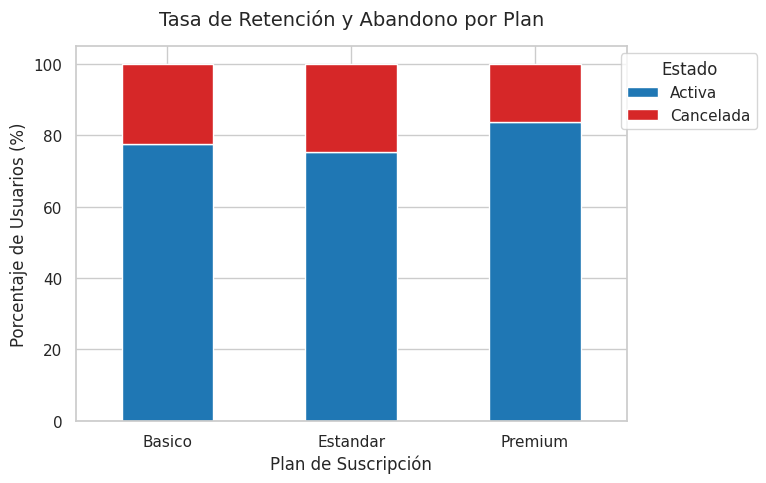

In [ ]:
df_abandono = pd.merge(df_subs, df_users[['user_id']], on='user_id')
abandono_crosstab = pd.crosstab(df_abandono['plan'], df_abandono['estado'], normalize='index') * 100

# Gráfico
ax = abandono_crosstab.plot(kind='bar', stacked=True, color=['#1f77b4', '#d62728'], figsize=(8, 5))
plt.title('Tasa de Retención y Abandono por Plan', fontsize=14, pad=15)
plt.ylabel('Porcentaje de Usuarios (%)', fontsize=12)
plt.xlabel('Plan de Suscripción', fontsize=12)
plt.legend(title='Estado', loc='upper right', bbox_to_anchor=(1.25, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Gráfico propuesto: Barras apiladas al 100%.

Hallazgo: El plan Estándar presenta la mayor fuga de clientes con un 24.8% de cancelaciones, seguido de cerca por el plan Básico (22.4%). Por el contrario, el plan Premium demuestra la mayor fidelidad, con solo un 16.3% de abandono.

# **2. Gráfico de Barras Horizontales: Top Géneros por Engagement**

/tmp/ipykernel_3595/3715229279.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_generos.values, y=top_generos.index, palette="viridis")


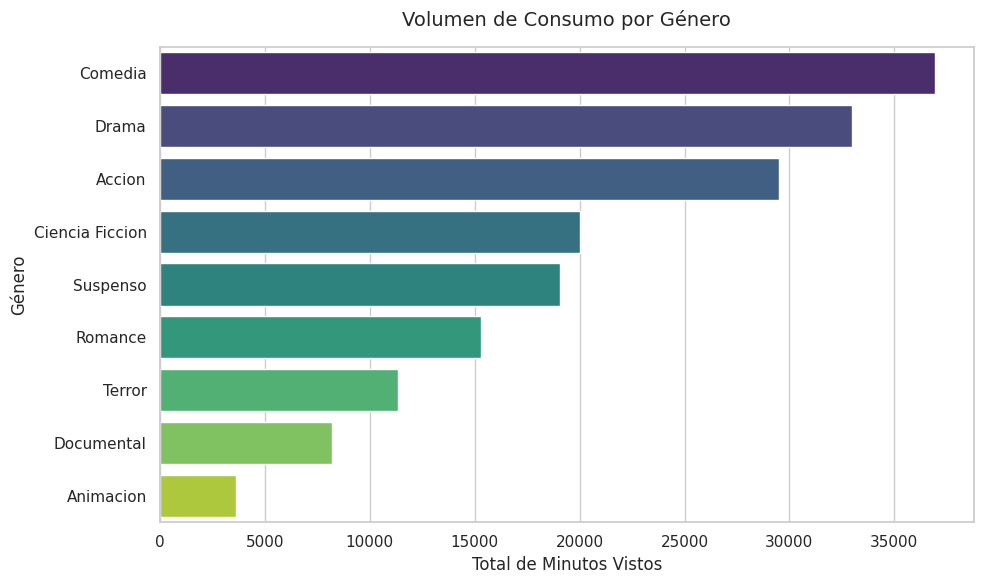

In [ ]:
df_engagement = pd.merge(df_repro, df_content[['content_id', 'genero']], on='content_id')
top_generos = df_engagement.groupby('genero')['minutos_vistos'].sum().sort_values(ascending=False)

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x=top_generos.values, y=top_generos.index, palette="viridis")
plt.title('Volumen de Consumo por Género', fontsize=14, pad=15)
plt.xlabel('Total de Minutos Vistos', fontsize=12)
plt.ylabel('Género', fontsize=12)
plt.tight_layout()
plt.show()

Gráfico propuesto: Barras horizontales ordenadas de mayor a menor.

Hallazgo: La Comedia es el motor principal de la plataforma, acumulando más de 36,947 minutos de visualización, seguida por el Drama (32,976 minutos) y la Acción (29,523 minutos).

# **3. Gráfico de Barras Verticales: UX y Completitud por Dispositivo**

/tmp/ipykernel_3595/3124807056.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=completitud_dispositivo.index, y=completitud_dispositivo.values, palette="magma")


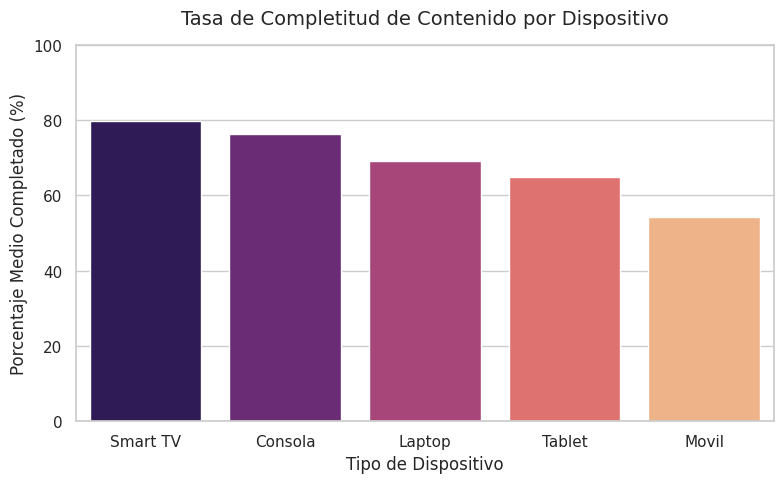

In [ ]:
df_ux = pd.merge(df_repro, df_devices[['device_id', 'tipo_dispositivo']], on='device_id', how='left').dropna(subset=['tipo_dispositivo'])
completitud_dispositivo = df_ux.groupby('tipo_dispositivo')['porcentaje_completado'].mean().sort_values(ascending=False)

# Gráfico
plt.figure(figsize=(8, 5))
sns.barplot(x=completitud_dispositivo.index, y=completitud_dispositivo.values, palette="magma")
plt.title('Tasa de Completitud de Contenido por Dispositivo', fontsize=14, pad=15)
plt.ylabel('Porcentaje Medio Completado (%)', fontsize=12)
plt.xlabel('Tipo de Dispositivo', fontsize=12)
plt.ylim(0, 100) # Fija el eje Y hasta el 100%
plt.tight_layout()
plt.show()

Gráfico propuesto: Barras verticales o diagrama de caja (Boxplot).

Hallazgo: Existe una brecha crítica en el hardware de consumo. Los espectadores en Smart TV completan en promedio el 79.7% del contenido que inician. Sin embargo, en dispositivos móviles esta métrica se desploma a un 54.1%.

# **4. Gráfico de Dispersión: Calidad Percibida vs Consumo**

/tmp/ipykernel_3595/4066143404.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(df_scatter['Minutos_Vistos'][i] + 500,
/tmp/ipykernel_3595/4066143404.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_scatter['Calificacion_Promedio'][i],


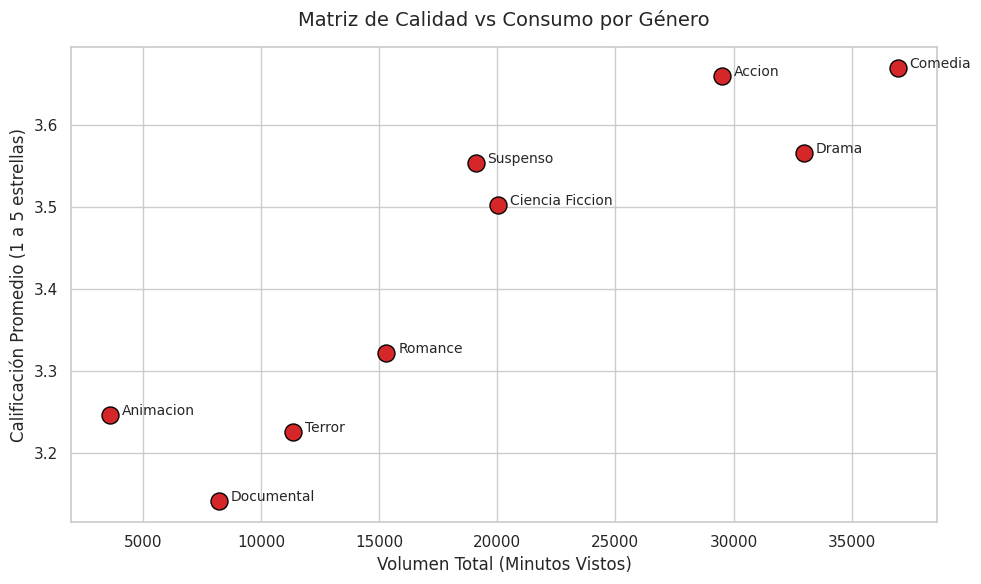

In [ ]:
#cruzar calificaciones con minutos vistos
df_calif_content = pd.merge(df_calif, df_content[['content_id', 'genero']], on='content_id')
rating_genero = df_calif_content.groupby('genero')['calificacion'].mean()

# Usamos la variable 'top_generos' creada en el paso 2
df_scatter = pd.DataFrame({'Minutos_Vistos': top_generos, 'Calificacion_Promedio': rating_genero}).dropna()

# Gráfico
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_scatter, x='Minutos_Vistos', y='Calificacion_Promedio', s=150, color='#d62728', edgecolor='black')

# Añadir etiquetas de texto a cada punto
for i in range(df_scatter.shape[0]):
    plt.text(df_scatter['Minutos_Vistos'][i] + 500,
             df_scatter['Calificacion_Promedio'][i],
             df_scatter.index[i],
             fontsize=10)

plt.title('Matriz de Calidad vs Consumo por Género', fontsize=14, pad=15)
plt.xlabel('Volumen Total (Minutos Vistos)', fontsize=12)
plt.ylabel('Calificación Promedio (1 a 5 estrellas)', fontsize=12)
plt.tight_layout()
plt.show()

Gráfico propuesto: Gráfico de dispersión (Scatter plot) cruzando "Minutos Vistos" en el eje X y "Calificación" en el eje Y, agrupado por género.

Hallazgo: La Comedia y la Acción no solo son populares en minutos vistos, sino que también lideran la satisfacción del cliente, promediando calificaciones de 3.66 y 3.65 sobre 5, respectivamente. El Drama baja ligeramente a 3.56.

# **5. Gráfico de Líneas: Evolución Temporal del Consumo**

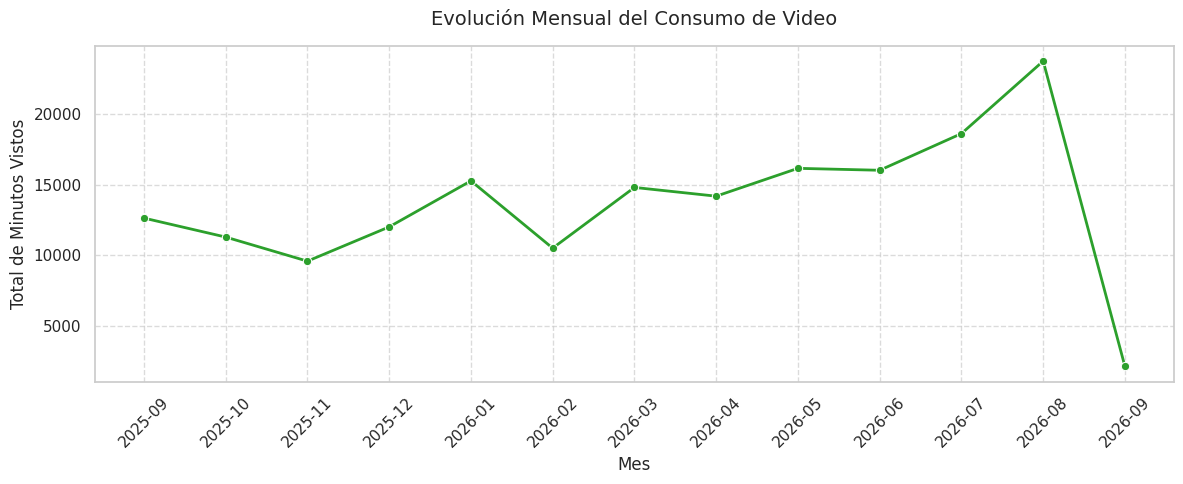

In [ ]:
#Agrupar reproducciones por mes
df_repro['fecha'] = pd.to_datetime(df_repro['fecha'])
# Agrupamos por mes y año para suavizar la línea (M = Month end frequency)
consumo_temporal = df_repro.groupby(df_repro['fecha'].dt.to_period('M'))['minutos_vistos'].sum().reset_index()
consumo_temporal['fecha'] = consumo_temporal['fecha'].astype(str) # Convertir a string para graficar

# Gráfico
plt.figure(figsize=(12, 5))
sns.lineplot(data=consumo_temporal, x='fecha', y='minutos_vistos', marker='o', linewidth=2, color='#2ca02c')
plt.title('Evolución Mensual del Consumo de Video', fontsize=14, pad=15)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Total de Minutos Vistos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Gráfico propuesto: Gráfico de líneas cruzando la fecha de reproducción con el volumen de minutos.

Hallazgo: El consumo de contenido muestra una tendencia general al alza durante el año 2026, alcanzando su punto máximo histórico en agosto de 2026 con más de 23,700 minutos vistos. Se observan caídas significativas en los meses de noviembre de 2025 (9,588 minutos) y febrero de 2026 (10,510 minutos), lo que podría indicar estacionalidad negativa o falta de estrenos atractivos en esos periodos.

Cabe recalcar que el mes de septiembre de 2026 registra una caída abrupta, lo cual es normal si los datos se extrajeron a principios de ese mes y el registro está incompleto.